# Team Humphrey

In [101]:
# Import dependencies
import pandas as pd
import os
import numpy as np
from statsmodels.formula.api import ols
import statsmodels.imputation.mice as mice
import statsmodels.regression.linear_model as sm
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
from statsmodels.formula.api import ols
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import norm
from statsmodels.formula.api import ols
from statsmodels.stats.diagnostic import het_breuschpagan
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from numpy import sqrt

# Remove the limit on the number of columns displayed
pd.set_option('display.max_columns', None)

## Exploratory Data Analysis

### Import and Explore Data

In [ ]:
# Define the paths to train and test data
train_path = os.path.join(os.path.curdir, "train.csv")
test_path = os.path.join(os.path.curdir, "test.csv")

# Store the data in DataFrame
train_df = pd.read_csv(train_path, index_col="Id")
test_df = pd.read_csv(test_path, index_col="Id")

# Read the first three rows of the train data
print(train_df.head(3))
print("")

# Show the descriptive statistics
print(train_df.describe())
print("")

# Show the dtype and null-value count
print(train_df.info())

    MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
Id                                                                    
1           60       RL         65.0     8450   Pave   NaN      Reg   
2           20       RL         80.0     9600   Pave   NaN      Reg   
3           60       RL         68.0    11250   Pave   NaN      IR1   

   LandContour Utilities LotConfig LandSlope Neighborhood Condition1  \
Id                                                                     
1          Lvl    AllPub    Inside       Gtl      CollgCr       Norm   
2          Lvl    AllPub       FR2       Gtl      Veenker      Feedr   
3          Lvl    AllPub    Inside       Gtl      CollgCr       Norm   

   Condition2 BldgType HouseStyle  OverallQual  OverallCond  YearBuilt  \
Id                                                                       
1        Norm     1Fam     2Story            7            5       2003   
2        Norm     1Fam     1Story            6            8  

### Data Cleaning and Feature Engineering

LotFrontage
NaN      259
60.0     143
70.0      70
80.0      69
50.0      57
        ... 
137.0      1
38.0       1
33.0       1
150.0      1
46.0       1
Name: count, Length: 111, dtype: int64


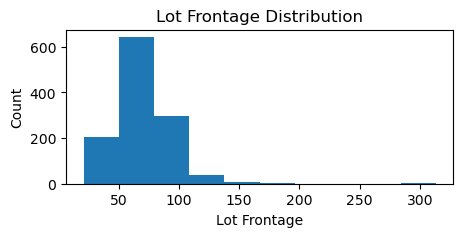

In [103]:
########## LotFrontage ##########

# 'LotFrontage' is Missing at Random (MAR); the variable can be explained by other variables such as 'Neighborhood'
# The histogram shows that the distribution is heavily right-skewed. Therefore, we will use median to replace the missing values.
# Group by Neighborhood and fill the 259 missing LotFrontage values with the median of each group
print(train_df["LotFrontage"].value_counts(dropna=False))

plt.figure(figsize=(5,2))
plt.hist(train_df["LotFrontage"], bins=10)
plt.xlabel("Lot Frontage")
plt.ylabel("Count")
plt.title("Lot Frontage Distribution")
plt.show()

In [104]:
def clean_housing_data(df):
    """
    Cleans, maps, and imputes missing values for the Ames Housing dataset.
    """
    # Create a copy so we don't accidentally overwrite the original raw data in memory
    df = df.copy()

    ########## Pre-cleaning Patch ##########
    
    # This step is essential because our logic includes separating how we action null values based on whether
    # these null values occur because the feature physically does not exist (structural nulls, mapped to 0) 
    # or because they are Missing Completely at Random (mapped to mode).

    # Patch missing continuous area/count variables with 0
    rogue_num_cols = [
        'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 
        'BsmtFullBath', 'BsmtHalfBath', 'GarageCars', 'GarageArea'
    ]
    df[rogue_num_cols] = df[rogue_num_cols].fillna(0)

    # 2. Patch missing essential categories with the mode (before mapping)
    # Every house has a kitchen and functionality, therefore the nulls must be errors.
    rogue_cat_cols = ['KitchenQual', 'Functional']
    for col in rogue_cat_cols:
        df[col] = df[col].fillna(df[col].mode()[0])

    ########## LotFrontage ##########
    # Group by Neighborhood and fill the 259 missing LotFrontage values with the median of each group
    df['LotFrontage'] = df.groupby('Neighborhood')['LotFrontage'].transform(lambda x: x.fillna(x.median()))

    ########## Alley ##########
    # 'Alley' missing values simply mean there is no alley access.
    df["Alley"] = df["Alley"].fillna('None')

    ########## MasVnrType ##########
    # Identify houses that have veneer area, but are missing the type
    veneer_anomaly = (df['MasVnrArea'] > 0) & (df['MasVnrType'].isnull())
    # Fill the anomalies with the most frequent type
    df.loc[veneer_anomaly, 'MasVnrType'] = df['MasVnrType'].mode()[0]
    # Fill the 'No Veneer' houses; if type is still missing, it means there is no veneer. 
    df['MasVnrType'] = df['MasVnrType'].fillna('None')
    # If area is missing, it means there is 0 area.
    df['MasVnrArea'] = df['MasVnrArea'].fillna(0.0)

    ########## Electrical ##########
    # Fill the single missing value with the most frequent electrical system
    df['Electrical'] = df['Electrical'].fillna(df['Electrical'].mode()[0])

    # Convert MSSubClass from integer to string so it is treated as a categorical variable
    df["MSSubClass"] = df["MSSubClass"].astype(str).str.strip()

    # Calculate the age of the house and the age since re-modeling at the time of sale
    df["HouseAge"] = df["YrSold"] - df["YearBuilt"]
    df["RemodelAge"] = df["YrSold"] - df["YearRemodAdd"]
    df = df.drop(columns=["YearBuilt", "YearRemodAdd"])

    ########## Convert Categorical Values to Ordinal ##########
    ordinal_cols_to_strip = [
        'ExterQual', 'ExterCond', 'BsmtQual', 'HeatingQC', 'KitchenQual', 
        'FireplaceQu', 'GarageQual', 'GarageCond', 'PoolQC', 'BsmtFinType1', 
        'BsmtFinType2', 'Functional', 'Fence', 'BsmtExposure'
    ]
    for col in ordinal_cols_to_strip:
        df[col] = df[col].str.capitalize().str.strip()

    # 1. Standard Quality Map
    quality_map = {'Ex': 5, 'Gd': 4, 'Ta': 3, 'Fa': 2, 'Po': 1}
    standard_ord_cols = ['ExterQual', 'ExterCond', 'BsmtQual', 'HeatingQC', 'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond', 'PoolQC']
    for col in standard_ord_cols:
        df[col] = df[col].map(quality_map)

    # 2. Basement Finish Map
    type_map = {'Glq': 6, 'Alq': 5, 'Blq': 4, 'Rec': 3, 'Lwq': 2, 'Unf': 1}
    for col in ["BsmtFinType1", "BsmtFinType2"]:
        df[col] = df[col].map(type_map)

    # 3. Functional Map
    func_map = {'Typ': 7, 'Min1': 6, 'Min2': 5, 'Mod': 4, 'Maj1': 3, 'Maj2': 2, 'Sev': 1, 'Sal': 0}
    df["Functional"] = df["Functional"].map(func_map)

    # 4. Fence Map
    fence_map = {'Gdprv': 4, 'Mnprv': 3, 'Gdwo': 2, 'Mnww': 1}
    df["Fence"] = df["Fence"].map(fence_map)

    # 5. Basement Exposure Map
    exposure_map = {'Gd': 4, 'Av': 3, 'Mn': 2, 'No': 1}
    df["BsmtExposure"] = df["BsmtExposure"].map(exposure_map)

    ########## Fill True Nulls & Patch Remaining Anomalies ##########
    
    # Basement Data
    bsmt_cols = ['BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2']
    for col in bsmt_cols:
        anomaly = (df['TotalBsmtSF'] > 0) & (df[col].isnull())
        df.loc[anomaly, col] = df[col].mode()[0]
    df[bsmt_cols] = df[bsmt_cols].fillna(0)

    # Fireplace Data
    fire_anomaly = (df['Fireplaces'] > 0) & (df['FireplaceQu'].isnull())
    df.loc[fire_anomaly, 'FireplaceQu'] = df['FireplaceQu'].mode()[0]
    df['FireplaceQu'] = df['FireplaceQu'].fillna(0)

    # Garage Data
    garage_ordinal_cols = ['GarageQual', 'GarageCond']
    for col in garage_ordinal_cols:
        anomaly = (df['GarageArea'] > 0) & (df[col].isnull())
        df.loc[anomaly, col] = df[col].mode()[0]
    df[garage_ordinal_cols] = df[garage_ordinal_cols].fillna(0)
    
    garage_cat_cols = ['GarageType', 'GarageFinish']
    df[garage_cat_cols] = df[garage_cat_cols].fillna('None')
    df['GarageYrBlt'] = df['GarageYrBlt'].fillna(0)

    # Pool Data
    pool_anomaly = (df['PoolArea'] > 0) & (df['PoolQC'].isnull())
    if not df[pool_anomaly].empty:
        df.loc[pool_anomaly, 'PoolQC'] = df['PoolQC'].mode()[0]
    df['PoolQC'] = df['PoolQC'].fillna(0)

    # Fence Data
    df['Fence'] = df['Fence'].fillna(0)

    # Miscellaneous Feature Data
    misc_anomaly = (df['MiscVal'] > 0) & (df['MiscFeature'].isnull())
    if not df[misc_anomaly].empty:
        df.loc[misc_anomaly, 'MiscFeature'] = df['MiscFeature'].mode()[0]
    df['MiscFeature'] = df['MiscFeature'].fillna('None')

    ########## Dummy Variables ##########
    # Convert all remaining categorical variables to dummies, dropping the first to avoid multicollinearity
    df = pd.get_dummies(df, drop_first=True, dtype=int)
    
    return df

# Execute the cleaning
train_clean = clean_housing_data(train_df)
test_clean = clean_housing_data(test_df)

In [105]:
# Print to view the first three rows of both train and test DataFrames
train_clean.head(3)

,LotFrontage,LotArea,OverallQual,OverallCond,MasVnrArea,ExterQual,ExterCond,BsmtQual,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,HeatingQC,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageYrBlt,GarageCars,GarageArea,GarageQual,GarageCond,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscVal,MoSold,YrSold,SalePrice,HouseAge,RemodelAge,MSSubClass_160,MSSubClass_180,MSSubClass_190,MSSubClass_20,MSSubClass_30,MSSubClass_40,MSSubClass_45,MSSubClass_50,MSSubClass_60,MSSubClass_70,MSSubClass_75,MSSubClass_80,MSSubClass_85,MSSubClass_90,MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM,Street_Pave,Alley_None,Alley_Pave,LotShape_IR2,LotShape_IR3,LotShape_Reg,LandContour_HLS,LandContour_Low,LandContour_Lvl,Utilities_NoSeWa,LotConfig_CulDSac,LotConfig_FR2,LotConfig_FR3,LotConfig_Inside,LandSlope_Mod,LandSlope_Sev,Neighborhood_Blueste,Neighborhood_BrDale,Neighborhood_BrkSide,Neighborhood_ClearCr,Neighborhood_CollgCr,Neighborhood_Crawfor,Neighborhood_Edwards,Neighborhood_Gilbert,Neighborhood_IDOTRR,Neighborhood_MeadowV,Neighborhood_Mitchel,Neighborhood_NAmes,Neighborhood_NPkVill,Neighborhood_NWAmes,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker,Condition1_Feedr,Condition1_Norm,Condition1_PosA,Condition1_PosN,Condition1_RRAe,Condition1_RRAn,Condition1_RRNe,Condition1_RRNn,Condition2_Feedr,Condition2_Norm,Condition2_PosA,Condition2_PosN,Condition2_RRAe,Condition2_RRAn,Condition2_RRNn,BldgType_2fmCon,BldgType_Duplex,BldgType_Twnhs,BldgType_TwnhsE,HouseStyle_1.5Unf,HouseStyle_1Story,HouseStyle_2.5Fin,HouseStyle_2.5Unf,HouseStyle_2Story,HouseStyle_SFoyer,HouseStyle_SLvl,RoofStyle_Gable,RoofStyle_Gambrel,RoofStyle_Hip,RoofStyle_Mansard,RoofStyle_Shed,RoofMatl_CompShg,RoofMatl_Membran,RoofMatl_Metal,RoofMatl_Roll,RoofMatl_Tar&Grv,RoofMatl_WdShake,RoofMatl_WdShngl,Exterior1st_AsphShn,Exterior1st_BrkComm,Exterior1st_BrkFace,Exterior1st_CBlock,Exterior1st_CemntBd,Exterior1st_HdBoard,Exterior1st_ImStucc,Exterior1st_MetalSd,Exterior1st_Plywood,Exterior1st_Stone,Exterior1st_Stucco,Exterior1st_VinylSd,Exterior1st_Wd Sdng,Exterior1st_WdShing,Exterior2nd_AsphShn,Exterior2nd_Brk Cmn,Exterior2nd_BrkFace,Exterior2nd_CBlock,Exterior2nd_CmentBd,Exterior2nd_HdBoard,Exterior2nd_ImStucc,Exterior2nd_MetalSd,Exterior2nd_Other,Exterior2nd_Plywood,Exterior2nd_Stone,Exterior2nd_Stucco,Exterior2nd_VinylSd,Exterior2nd_Wd Sdng,Exterior2nd_Wd Shng,MasVnrType_BrkFace,MasVnrType_None,MasVnrType_Stone,Foundation_CBlock,Foundation_PConc,Foundation_Slab,Foundation_Stone,Foundation_Wood,BsmtCond_Fa,BsmtCond_Gd,BsmtCond_Po,BsmtCond_TA,Heating_GasA,Heating_GasW,Heating_Grav,Heating_OthW,Heating_Wall,CentralAir_Y,Electrical_FuseF,Electrical_FuseP,Electrical_Mix,Electrical_SBrkr,GarageType_Attchd,GarageType_Basment,GarageType_BuiltIn,GarageType_CarPort,GarageType_Detchd,GarageType_None,GarageFinish_None,GarageFinish_RFn,GarageFinish_Unf,PavedDrive_P,PavedDrive_Y,MiscFeature_None,MiscFeature_Othr,MiscFeature_Shed,MiscFeature_TenC,SaleType_CWD,SaleType_Con,SaleType_ConLD,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
Id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,65.0,8450,7,5,196.0,4,3,4.0,1.0,6.0,706,1.0,0,150,856,5,856,854,0,1710,1,0,2,1,3,1,4,8,7,0,0.0,2003.0,2,548,3.0,3.0,0,61,0,0,0,0,0.0,0.0,0,2,2008,208500,5,5,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,1,1,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,

In [106]:
# Print to view the first three rows of both train and test DataFrames
test_clean.head(3)

,LotFrontage,LotArea,OverallQual,OverallCond,MasVnrArea,ExterQual,ExterCond,BsmtQual,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,HeatingQC,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageYrBlt,GarageCars,GarageArea,GarageQual,GarageCond,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscVal,MoSold,YrSold,HouseAge,RemodelAge,MSSubClass_150,MSSubClass_160,MSSubClass_180,MSSubClass_190,MSSubClass_20,MSSubClass_30,MSSubClass_40,MSSubClass_45,MSSubClass_50,MSSubClass_60,MSSubClass_70,MSSubClass_75,MSSubClass_80,MSSubClass_85,MSSubClass_90,MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM,Street_Pave,Alley_None,Alley_Pave,LotShape_IR2,LotShape_IR3,LotShape_Reg,LandContour_HLS,LandContour_Low,LandContour_Lvl,LotConfig_CulDSac,LotConfig_FR2,LotConfig_FR3,LotConfig_Inside,LandSlope_Mod,LandSlope_Sev,Neighborhood_Blueste,Neighborhood_BrDale,Neighborhood_BrkSide,Neighborhood_ClearCr,Neighborhood_CollgCr,Neighborhood_Crawfor,Neighborhood_Edwards,Neighborhood_Gilbert,Neighborhood_IDOTRR,Neighborhood_MeadowV,Neighborhood_Mitchel,Neighborhood_NAmes,Neighborhood_NPkVill,Neighborhood_NWAmes,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker,Condition1_Feedr,Condition1_Norm,Condition1_PosA,Condition1_PosN,Condition1_RRAe,Condition1_RRAn,Condition1_RRNe,Condition1_RRNn,Condition2_Feedr,Condition2_Norm,Condition2_PosA,Condition2_PosN,BldgType_2fmCon,BldgType_Duplex,BldgType_Twnhs,BldgType_TwnhsE,HouseStyle_1.5Unf,HouseStyle_1Story,HouseStyle_2.5Unf,HouseStyle_2Story,HouseStyle_SFoyer,HouseStyle_SLvl,RoofStyle_Gable,RoofStyle_Gambrel,RoofStyle_Hip,RoofStyle_Mansard,RoofStyle_Shed,RoofMatl_Tar&Grv,RoofMatl_WdShake,RoofMatl_WdShngl,Exterior1st_AsphShn,Exterior1st_BrkComm,Exterior1st_BrkFace,Exterior1st_CBlock,Exterior1st_CemntBd,Exterior1st_HdBoard,Exterior1st_MetalSd,Exterior1st_Plywood,Exterior1st_Stucco,Exterior1st_VinylSd,Exterior1st_Wd Sdng,Exterior1st_WdShing,Exterior2nd_AsphShn,Exterior2nd_Brk Cmn,Exterior2nd_BrkFace,Exterior2nd_CBlock,Exterior2nd_CmentBd,Exterior2nd_HdBoard,Exterior2nd_ImStucc,Exterior2nd_MetalSd,Exterior2nd_Plywood,Exterior2nd_Stone,Exterior2nd_Stucco,Exterior2nd_VinylSd,Exterior2nd_Wd Sdng,Exterior2nd_Wd Shng,MasVnrType_BrkFace,MasVnrType_None,MasVnrType_Stone,Foundation_CBlock,Foundation_PConc,Foundation_Slab,Foundation_Stone,Foundation_Wood,BsmtCond_Fa,BsmtCond_Gd,BsmtCond_Po,BsmtCond_TA,Heating_GasW,Heating_Grav,Heating_Wall,CentralAir_Y,Electrical_FuseF,Electrical_FuseP,Electrical_SBrkr,GarageType_Attchd,GarageType_Basment,GarageType_BuiltIn,GarageType_CarPort,GarageType_Detchd,GarageType_None,GarageFinish_None,GarageFinish_RFn,GarageFinish_Unf,PavedDrive_P,PavedDrive_Y,MiscFeature_None,MiscFeature_Othr,MiscFeature_Shed,SaleType_CWD,SaleType_Con,SaleType_ConLD,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
Id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1461,80.0,11622,5,6,0.0,3,3,3.0,1.0,3.0,468.0,2.0,144.0,270.0,882.0,3,896,0,0,896,0.0,0.0,1,0,2,1,3,5,7,0,0.0,1961.0,1.0,730.0,3.0,3.0,140,0,0,0,120,0,0.0,3.0,0,6,2010,49,49,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,1,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,1,1,0,0,0,0,0,0,0,1,0,1,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0
1462,81.0,14267,6,6,108.0,3,3,3.0,1.0,5.0,923.0,

In [107]:
# Check the engineered Train data
print(train_clean.info())
print("")
print(train_clean.isnull().values.any())
print("")
print(train_clean.columns)
print("")
print(train_clean.shape)

<class 'pandas.core.frame.DataFrame'>
Index: 1460 entries, 1 to 1460
Columns: 225 entries, LotFrontage to SaleCondition_Partial
dtypes: float64(12), int32(175), int64(38)
memory usage: 1.5 MB
None

False

Index(['LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'MasVnrArea',
       'ExterQual', 'ExterCond', 'BsmtQual', 'BsmtExposure', 'BsmtFinType1',
       ...
       'SaleType_ConLI', 'SaleType_ConLw', 'SaleType_New', 'SaleType_Oth',
       'SaleType_WD', 'SaleCondition_AdjLand', 'SaleCondition_Alloca',
       'SaleCondition_Family', 'SaleCondition_Normal',
       'SaleCondition_Partial'],
      dtype='object', length=225)

(1460, 225)


In [108]:
# Check the engineered Test data
print(test_clean.info())
print("")
print(test_clean.isnull().values.any())
print("")
print(test_clean.columns)
print("")
print(test_clean.shape)

<class 'pandas.core.frame.DataFrame'>
Index: 1459 entries, 1461 to 2919
Columns: 209 entries, LotFrontage to SaleCondition_Partial
dtypes: float64(20), int32(160), int64(29)
memory usage: 1.4 MB
None

False

Index(['LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'MasVnrArea',
       'ExterQual', 'ExterCond', 'BsmtQual', 'BsmtExposure', 'BsmtFinType1',
       ...
       'SaleType_ConLI', 'SaleType_ConLw', 'SaleType_New', 'SaleType_Oth',
       'SaleType_WD', 'SaleCondition_AdjLand', 'SaleCondition_Alloca',
       'SaleCondition_Family', 'SaleCondition_Normal',
       'SaleCondition_Partial'],
      dtype='object', length=209)

(1459, 209)


In [ ]:
# Problem: The number of columns in the test set does not match that in the train set.
# Reason: This is because pd.get_dummies() creates binary columns based only on the unique categories present in the current dataset. 
# If the training data contains a specific category (e.g., a rare Roof Material) that is completely absent from the testing data, the 
# testing dataset will not generate that specific dummy column, causing a matrix shape mismatch when we run our regression model.

# Solution: We use .align() to fill missing categories in the testing data with 0

# Isolate the target variable (Y) from the training set
y_train = train_clean['SalePrice']

# Isolate the predictor variables (X)
X_train = train_clean.drop(columns=['SalePrice'])
X_test = test_clean.copy()

# Align the columns so X_test perfectly matches the shape of X_train
# Any dummy columns present in train but missing in test will be added and filled with 0
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# Verification
print(f"Final X_train shape: {X_train.shape}")
print(f"Final X_test shape:  {X_test.shape}")

Final X_train shape: (1460, 224)
Final X_test shape:  (1459, 224)


## Modeling